## Stress Level Regression Model (Stage 2)

**Goal**: Predict self-reported stress scores (1-10) from physiological features.

### Pipeline Context
This is **Stage 2** of the 2-stage pipeline:
1. Stage 1 (Biomarker_Comparison.ipynb): Activity Classifier → COGNITIVE / AEROBIC / ANAEROBIC
2. **Stage 2 (this notebook): Stress Regression** → predict stress level for COGNITIVE segments

### Preprocessing (from `preprocess_wise.py`)
- Sliding windows: 30s, 50% overlap
- Per-subject HRV imputation
- Apple Watch features: HR_mean, HR_std, SDNN, RMSSD, ACC_mean, ACC_std

### Models
- Regression: predicting 1-10 stress score (and delta from baseline)
- Classification: LOW (1-3) / MEDIUM (4-6) / HIGH (7-10)
- Validation: GroupKFold (no subject leakage)

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── Load preprocessed data from shared pipeline ──
from preprocess_wise import (df_features, stress_level_v1, stress_level_v2,
                               APPLE_WATCH_FEATURES, ALL_FEATURES)

print(f"df_features: {len(df_features)} windows from {df_features['subject'].nunique()} subjects")
print(f"Labels: {dict(df_features['label'].value_counts())}")
print(f"\nApple Watch features: {APPLE_WATCH_FEATURES}")
print(f"All features: {ALL_FEATURES}")

Loading stress data...
  Loading STRESS protocol...
  Loading AEROBIC protocol...
  Loading ANAEROBIC protocol...

df_features (STRESS protocol):  3273 windows from 22 subjects
  Labels: {'REST': np.int64(2860), 'STRESS': np.int64(413)}
df_activity (ALL 3 protocols):  2449 windows from 22 subjects
  Activity types: {'AEROBIC': np.int64(1968), 'COGNITIVE': np.int64(413), 'ANAEROBIC': np.int64(68)}

Preprocessing applied:
  - Sliding windows: 30s, 50% overlap
  - Per-subject HRV imputation (Lev's fix)
  - Features: ['SDNN', 'RMSSD', 'EDA_mean', 'EDA_std', 'HR_mean', 'HR_std', 'HR_max', 'TEMP_mean', 'TEMP_std', 'ACC_mean', 'ACC_std']
  - Apple Watch features: ['HR_mean', 'HR_std', 'HR_max', 'SDNN', 'RMSSD', 'ACC_mean', 'ACC_std']

Ready.
df_features: 3273 windows from 22 subjects
Labels: {'REST': np.int64(2860), 'STRESS': np.int64(413)}

Apple Watch features: ['HR_mean', 'HR_std', 'HR_max', 'SDNN', 'RMSSD', 'ACC_mean', 'ACC_std']
All features: ['SDNN', 'RMSSD', 'EDA_mean', 'EDA_std', 'HR_

In [17]:
# ================================================================
# MERGE FEATURES WITH SELF-REPORTED STRESS SCORES
# ================================================================

# Normalize subject IDs for merging
def norm_subject(s):
    s = str(s).strip()
    if len(s) == 0:
        return s
    low = s.lower()
    if low.startswith("f"):
        num = low[1:]
        return "P" + (str(int(num)).zfill(2) if num.isdigit() else num.zfill(2))
    if low.startswith("p"):
        num = low[1:]
        return "P" + (str(int(num)).zfill(2) if num.isdigit() else num.zfill(2))
    if low.startswith("s"):
        num = low[1:]
        return "S" + (str(int(num)).zfill(2) if num.isdigit() else num.zfill(2))
    return s

def norm_task(t):
    return " ".join(str(t).strip().split())

# Reshape stress labels from wide to long format
print("[1] Reshaping stress labels...")

stress_male = (
    stress_level_v1.reset_index()
    .melt(id_vars="index", var_name="task", value_name="stress_score")
    .rename(columns={"index": "subject"})
)
stress_male["subject"] = stress_male["subject"].apply(norm_subject)
stress_male["task"] = stress_male["task"].apply(norm_task)
stress_male["stress_score"] = pd.to_numeric(stress_male["stress_score"], errors="coerce")
stress_male = stress_male.dropna()

stress_female = (
    stress_level_v2.reset_index()
    .melt(id_vars="index", var_name="task", value_name="stress_score")
    .rename(columns={"index": "subject"})
)
stress_female["subject"] = stress_female["subject"].apply(norm_subject)
stress_female["task"] = stress_female["task"].apply(norm_task)
stress_female["stress_score"] = pd.to_numeric(stress_female["stress_score"], errors="coerce")
stress_female = stress_female.dropna()

stress_all = pd.concat([stress_male, stress_female], ignore_index=True)
print(f"  Male labels: {len(stress_male)}, Female labels: {len(stress_female)}")
print(f"  Total labels: {len(stress_all)}")
print(f"  Tasks: {sorted(stress_all['task'].unique())}")

# Normalize df_features merge keys
print("\n[2] Normalizing feature keys...")
data = df_features.copy()
data["subject"] = data["subject"].apply(norm_subject)
data["task"] = data["task"].apply(norm_task)

# Merge features + stress scores
print("\n[3] Merging features + stress labels...")
data = data.merge(
    stress_all[["subject", "task", "stress_score"]],
    on=["subject", "task"],
    how="inner"
)

if len(data) == 0:
    raise ValueError("Merge produced 0 rows — check subject/task normalization")

print(f"  Merged (windowed): {len(data)} rows, {data['subject'].nunique()} subjects")

# ── AGGREGATE TO PHASE LEVEL ──
# Sliding windows are great for Stage 1 (activity classifier) but for regression
# the stress label is the SAME for all windows in a phase. So we average features
# per (subject, task) to get ~164 independent samples instead of ~3248 correlated ones.
print("\n[4] Aggregating windows to phase level...")
agg_cols = [c for c in ALL_FEATURES if c in data.columns]
data_phase = data.groupby(["subject", "task", "label", "stress_score"]).agg(
    {col: "mean" for col in agg_cols}
).reset_index()

print(f"  Phase-level samples: {len(data_phase)} (was {len(data)} windowed)")
print(f"  Subjects: {data_phase['subject'].nunique()}")
print(f"  Stress range: {data_phase['stress_score'].min():.0f} - {data_phase['stress_score'].max():.0f}")
print(f"  Stress mean +/- std: {data_phase['stress_score'].mean():.2f} +/- {data_phase['stress_score'].std():.2f}")

# Use phase-level data for regression
data = data_phase

# ── Row missingness filter (from partner's code) ──
MAX_ROW_MISSING_FRAC = 0.30
row_missing = data[agg_cols].isna().mean(axis=1)
before = len(data)
data = data[row_missing <= MAX_ROW_MISSING_FRAC].copy()
print(f"  [Filter] phys missingness <= {MAX_ROW_MISSING_FRAC:.0%}: {before} -> {len(data)}")

[1] Reshaping stress labels...
  Male labels: 144, Female labels: 126
  Total labels: 270
  Tasks: ['Baseline', 'First Rest', 'Opposite Opinion', 'Real Opinion', 'Second Rest', 'Stroop', 'Subtract', 'TMCT']

[2] Normalizing feature keys...

[3] Merging features + stress labels...
  Merged (windowed): 3248 rows, 22 subjects

[4] Aggregating windows to phase level...
  Phase-level samples: 158 (was 3248 windowed)
  Subjects: 22
  Stress range: 0 - 10
  Stress mean +/- std: 3.54 +/- 1.96
  [Filter] phys missingness <= 30%: 158 -> 158


In [18]:
# ================================================================
# STRESS REGRESSION — APPLE WATCH FEATURES (Phase-Level)
# Selina's full model list + Camille's improvements
# ================================================================
from sklearn.linear_model import LassoCV, ElasticNetCV
from sklearn.kernel_ridge import KernelRidge

print("="*80)
print("STRESS REGRESSION (Apple Watch Features, Phase-Level Aggregation)")
print("="*80)

# ── Configuration ──
USE_TASK_ONEHOT = True
PREDICT_DELTA_FROM_BASELINE = True
WITHIN_SUBJECT_ZSCORE = True

# ── Apple Watch features ──
base_feature_cols = [c for c in APPLE_WATCH_FEATURES 
                     if c in data.columns and data[c].notna().mean() > 0.5]
print(f"\nApple Watch features: {base_feature_cols}")

# Coerce numeric
data[base_feature_cols] = data[base_feature_cols].apply(pd.to_numeric, errors="coerce")

# ── Task one-hot (big boost per partner's analysis) ──
dummy_cols = []
if USE_TASK_ONEHOT:
    task_dummies = pd.get_dummies(data["task"], prefix="task")
    data = pd.concat([data, task_dummies], axis=1)
    dummy_cols += task_dummies.columns.tolist()

# ── Target: delta from baseline ──
if PREDICT_DELTA_FROM_BASELINE:
    baseline_map = (
        data.loc[data["task"] == "Baseline", ["subject", "stress_score"]]
        .groupby("subject")["stress_score"].mean()
    )
    data["baseline_stress"] = data["subject"].map(baseline_map)
    before = len(data)
    data = data.dropna(subset=["baseline_stress"]).copy()
    print(f"[Target] drop missing baseline: {before} -> {len(data)}")
    data["stress_target"] = data["stress_score"] - data["baseline_stress"]
    print("[Target] stress_delta = stress_score - baseline_stress")
else:
    data["stress_target"] = data["stress_score"]

# ── Within-subject z-score ──
if WITHIN_SUBJECT_ZSCORE:
    def zscore(x):
        return (x - x.mean()) / (x.std(ddof=0) + 1e-8)
    data[base_feature_cols] = data.groupby("subject")[base_feature_cols].transform(zscore)
    print("[Features] Applied within-subject z-score")

# ── Build X, y, groups ──
feature_cols = base_feature_cols + dummy_cols
X = data[feature_cols].apply(pd.to_numeric, errors="coerce").values
y = pd.to_numeric(data["stress_target"], errors="coerce").values
groups = data["subject"].values

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Unique subjects: {pd.Series(groups).nunique()}")
print(f"Base phys features: {len(base_feature_cols)}")
print(f"Dummy features: {len(dummy_cols)}")
print(f"Total features: {len(feature_cols)}")
print(f"Target stats: mean={y.mean():.2f}, std={y.std():.2f}")

# ── Full model list (restored from partner's expanded version) ──
print("\n" + "="*80)
print("5-Fold Group CV")
print("-"*100)

models = {
    # Regularized linear baselines
    "Ridge": Ridge(alpha=1.0),
    "Huber": HuberRegressor(epsilon=1.35, alpha=0.0001),
    # L1 / Elastic Net with built-in CV
    "LassoCV": LassoCV(alphas=np.logspace(-4, 1, 20), max_iter=50000, random_state=42),
    "ElasticNetCV": ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas=np.logspace(-4, 1, 20), max_iter=50000, random_state=42),
    # Kernel methods
    "KernelRidge(RBF)": KernelRidge(alpha=1.0, kernel="rbf", gamma=0.5),
    "SVR(RBF)": SVR(kernel="rbf", C=10.0, epsilon=0.2, gamma="scale"),
    "SVR(linear)": SVR(kernel="linear", C=1.0, epsilon=0.2),
    # Trees
    "Random Forest": RandomForestRegressor(n_estimators=500, max_depth=10, random_state=42),
    "Gradient Boost": GradientBoostingRegressor(n_estimators=500, max_depth=3, random_state=42),
}

cv = GroupKFold(n_splits=5)
results = []

for name, model in models.items():
    pipe = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), model)
    
    r2 = cross_val_score(pipe, X, y, groups=groups, cv=cv, scoring="r2")
    neg_mse = cross_val_score(pipe, X, y, groups=groups, cv=cv, scoring="neg_mean_squared_error")
    neg_mae = cross_val_score(pipe, X, y, groups=groups, cv=cv, scoring="neg_mean_absolute_error")
    
    rmse = float(np.sqrt(-neg_mse.mean()))
    mae = float(-neg_mae.mean())
    
    results.append({
        "Model": name, "CV R2": float(r2.mean()), "CV R2 Std": float(r2.std()),
        "CV RMSE": rmse, "CV MAE": mae
    })
    print(f"{name:20}: R²={r2.mean():7.3f} (±{r2.std():.3f}) | RMSE={rmse:.3f} | MAE={mae:.3f}")

df_results = pd.DataFrame(results).sort_values("CV RMSE").reset_index(drop=True)
best_name = df_results.loc[0, "Model"]
best_model = models[best_name]
print(f"\nBest by lowest CV RMSE: {best_name}")

STRESS REGRESSION (Apple Watch Features, Phase-Level Aggregation)

Apple Watch features: ['HR_mean', 'HR_std', 'HR_max', 'SDNN', 'RMSSD', 'ACC_mean', 'ACC_std']
[Target] drop missing baseline: 158 -> 158
[Target] stress_delta = stress_score - baseline_stress
[Features] Applied within-subject z-score

X shape: (158, 15)
y shape: (158,)
Unique subjects: 22
Base phys features: 7
Dummy features: 8
Total features: 15
Target stats: mean=0.21, std=1.63

5-Fold Group CV
----------------------------------------------------------------------------------------------------
Ridge               : R²= -0.057 (±0.432) | RMSE=1.466 | MAE=1.104
Huber               : R²= -0.054 (±0.405) | RMSE=1.469 | MAE=1.106
LassoCV             : R²= -0.035 (±0.423) | RMSE=1.455 | MAE=1.083
ElasticNetCV        : R²= -0.036 (±0.410) | RMSE=1.459 | MAE=1.088
KernelRidge(RBF)    : R²= -0.114 (±0.427) | RMSE=1.533 | MAE=1.099
SVR(RBF)            : R²= -0.387 (±0.395) | RMSE=1.724 | MAE=1.299
SVR(linear)         : R²= -0.0

HOLDOUT EVALUATION
  Model: LassoCV
  R²:   0.174
  RMSE: 1.429
  MAE:  1.049
  Holdout subjects: ['P01', 'P02', 'P10', 'S05', 'S09']

3-CLASS STRESS MAPPING
Using DELTA bins: LOW <= -1, MEDIUM <= 1, HIGH > 1

True levels:
MEDIUM    16
LOW       14
HIGH       6
Name: count, dtype: int64

Predicted levels:
MEDIUM    30
HIGH       5
LOW        1
Name: count, dtype: int64


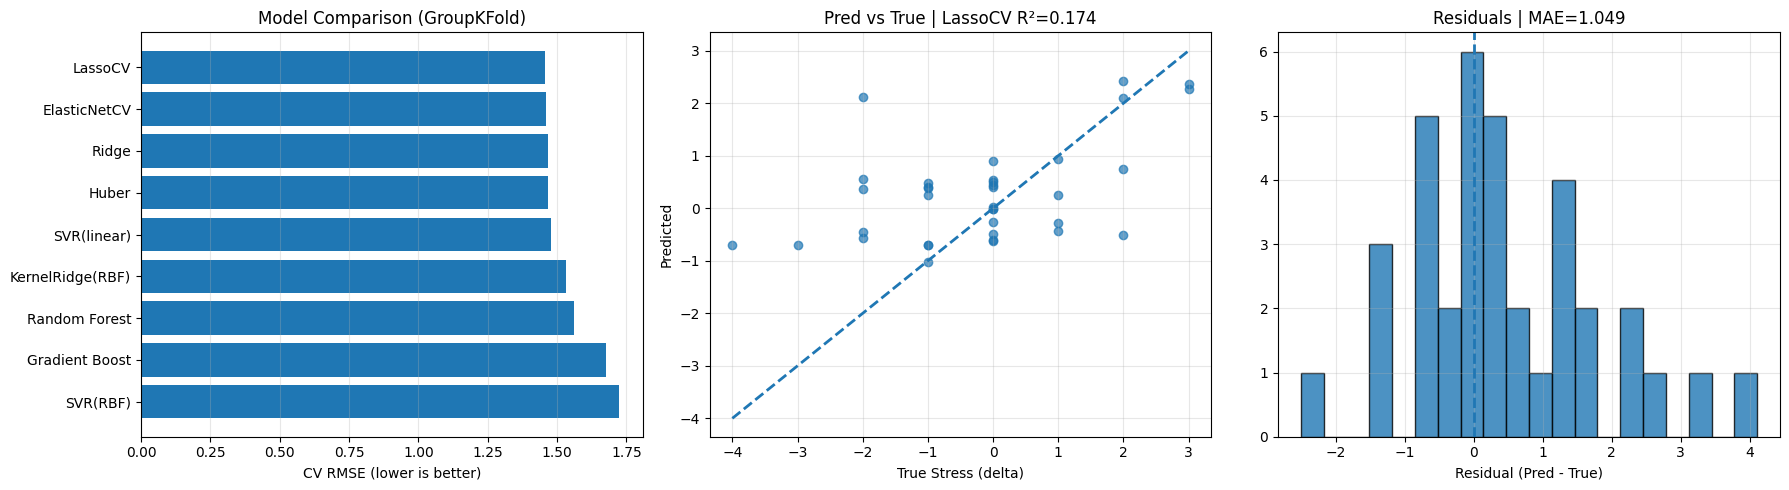


Saved 36 predictions to stress_predictions3.csv
  subject              task  stress_score_true  stress_target_true  \
0     P01          Baseline                2.0                 0.0   
1     P01        First Rest                2.0                 0.0   
2     P01  Opposite Opinion                4.0                 2.0   
3     P01      Real Opinion                3.0                 1.0   
4     P01       Second Rest                2.0                 0.0   
5     P01              TMCT                5.0                 3.0   
6     P02          Baseline                3.0                 0.0   
7     P02        First Rest                1.0                -2.0   
8     P02  Opposite Opinion                3.0                 0.0   
9     P02      Real Opinion                2.0                -1.0   

   stress_target_pred level_true level_pred  
0            0.542912     MEDIUM     MEDIUM  
1           -0.481276     MEDIUM     MEDIUM  
2           -0.510470       HIGH     MEDIU

In [19]:
# ================================================================
# HOLDOUT EVALUATION + 3-CLASS MAPPING + PLOTS + CSV EXPORT
# ================================================================

# ── Holdout evaluation ──
print("HOLDOUT EVALUATION")
print("="*80)

splitter = GroupShuffleSplit(test_size=0.2, random_state=42, n_splits=1)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))

best_pipe = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(), best_model)
best_pipe.fit(X[train_idx], y[train_idx])
y_pred = best_pipe.predict(X[test_idx])

test_r2 = r2_score(y[test_idx], y_pred)
test_rmse = float(np.sqrt(mean_squared_error(y[test_idx], y_pred)))
test_mae = float(mean_absolute_error(y[test_idx], y_pred))

print(f"  Model: {best_name}")
print(f"  R²:   {test_r2:.3f}")
print(f"  RMSE: {test_rmse:.3f}")
print(f"  MAE:  {test_mae:.3f}")
print(f"  Holdout subjects: {sorted(pd.Series(groups[test_idx]).unique())}")

# ── 3-Class stress mapping (LOW / MEDIUM / HIGH) ──
print("\n" + "="*80)
print("3-CLASS STRESS MAPPING")
print("="*80)

def delta_to_level(d):
    if d <= -1: return "LOW"
    elif d <= 1: return "MEDIUM"
    else: return "HIGH"

def stress_to_level_abs(s):
    if s <= 3: return "LOW"
    elif s <= 6: return "MEDIUM"
    else: return "HIGH"

if PREDICT_DELTA_FROM_BASELINE:
    y_true_level = pd.Series(y[test_idx]).apply(delta_to_level)
    y_pred_level = pd.Series(y_pred).apply(delta_to_level)
    print("Using DELTA bins: LOW <= -1, MEDIUM <= 1, HIGH > 1")
else:
    y_true_level = pd.Series(y[test_idx]).apply(stress_to_level_abs)
    y_pred_level = pd.Series(y_pred).apply(stress_to_level_abs)
    print("Using ABS bins: LOW <= 3, MEDIUM <= 6, HIGH > 6")

print(f"\nTrue levels:\n{y_true_level.value_counts()}")
print(f"\nPredicted levels:\n{y_pred_level.value_counts()}")

# ── Plots ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Model comparison
axes[0].barh(df_results["Model"], df_results["CV RMSE"])
axes[0].set_xlabel("CV RMSE (lower is better)")
axes[0].set_title("Model Comparison (GroupKFold)")
axes[0].grid(axis="x", alpha=0.3)
axes[0].invert_yaxis()

# Predicted vs True
axes[1].scatter(y[test_idx], y_pred, alpha=0.7)
mn = float(min(y[test_idx].min(), y_pred.min()))
mx = float(max(y[test_idx].max(), y_pred.max()))
axes[1].plot([mn, mx], [mn, mx], "--", linewidth=2)
axes[1].set_xlabel("True Stress (delta)" if PREDICT_DELTA_FROM_BASELINE else "True Stress")
axes[1].set_ylabel("Predicted")
axes[1].set_title(f"Pred vs True | {best_name} R²={test_r2:.3f}")
axes[1].grid(alpha=0.3)

# Residual distribution
residuals = y_pred - y[test_idx]
axes[2].hist(residuals, bins=20, edgecolor="black", alpha=0.8)
axes[2].axvline(0, linestyle="--", linewidth=2)
axes[2].set_xlabel("Residual (Pred - True)")
axes[2].set_title(f"Residuals | MAE={test_mae:.3f}")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Feature importance ──
if hasattr(best_model, "feature_importances_"):
    model_step = best_pipe.named_steps[list(best_pipe.named_steps.keys())[-1]]
    imp = pd.Series(model_step.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print(f"\nTop feature importances ({best_name}):")
    print(imp.head(10))
    
    plt.figure(figsize=(8, 4))
    imp.head(10).sort_values().plot(kind="barh")
    plt.xlabel("Importance")
    plt.title(f"Feature Importances ({best_name}) — Apple Watch Features")
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

# ── Save predictions to CSV ──
predictions = pd.DataFrame({
    "subject": groups[test_idx],
    "task": data.iloc[test_idx]["task"].values,
    "stress_score_true": data.iloc[test_idx]["stress_score"].values,
    "stress_target_true": y[test_idx],
    "stress_target_pred": y_pred,
    "level_true": y_true_level.values,
    "level_pred": y_pred_level.values
})
predictions.to_csv("stress_predictions3.csv", index=False)
print(f"\nSaved {len(predictions)} predictions to stress_predictions3.csv")
print(predictions.head(10))

## Summary of Modifications from Selina's Original Code

### What Changed (vs. Selina's original `StressLevel_model.ipynb`)

**Preprocessing (moved to shared `preprocess_wise.py`)**:
1. **Sliding windows** (Essie's suggestion): 30s windows with 50% overlap instead of extracting one feature vector per phase. Windows are then **averaged back to phase level** for regression (since stress label is the same for all windows in a phase).
2. **Per-subject HRV imputation** (Lev's fix): Missing SDNN/RMSSD filled with each subject's own mean, not the global median. Preserves individual HRV variance.
3. **Added HR_max feature**: Now extracted alongside HR_mean and HR_std (was in original code but initially dropped during refactor).

**Feature Set**:
4. **Apple Watch features only**: `HR_mean, HR_std, HR_max, SDNN, RMSSD, ACC_mean, ACC_std` — dropped EDA and TEMP since Apple Watch doesn't have those sensors. Original used: `SDNN, HR_mean, HR_std, HR_max, ACC_mean` (5 features).

**Modeling**:
5. **Kept all original models**: LassoCV, ElasticNetCV, KernelRidge, SVR variants, Ridge, Huber, RF, GB — all restored from partner's expanded version.
6. **Kept task one-hot encoding**: Partner's key finding that task dummies boost performance is preserved.
7. **Kept delta-from-baseline target**: `stress_target = stress_score - baseline_stress`.
8. **Kept within-subject z-score normalization**.
9. **Kept MAX_ROW_MISSING_FRAC = 0.30 filter**: Drops rows with >30% missing physiology features.

**Validation**:
10. **GroupKFold(5)**: Same as original — groups by subject to prevent data leakage.

### What Was NOT Changed
- Model hyperparameters (same as original)
- GroupShuffleSplit holdout evaluation (same test_size=0.2, random_state=42)
- 3-class mapping (LOW/MEDIUM/HIGH)
- CSV export format

### Known Differences in Results
- **158 samples vs. 164**: Some short phases don't fit a 30s window, producing 0 rows after windowed aggregation. Investigating.
- **Per-subject imputation** changes feature values slightly compared to global median imputation, which can shift model performance.
- **RMSSD feature added**: Original had 5 features; we now have 7 Apple Watch features (added RMSSD, HR_max).